# 제주 버스 도착 시간 예측을 위한 XGBoost 하이퍼파라미터 튜닝

이 노트북은 `jeju_bus_xgboost_hyperparameter_tuning.ipynb` 강의 슬라이드(파라메터 튜닝/모델 시각화)를 바탕으로 코드를 복원한 복습용 노트북입니다.

- **문제 유형**: 제주 버스 다음 정류장 도착 시간 예측 — 회귀(Regression)
- **핵심 모델**: XGBoost Regressor
- **핵심 실습 흐름**: 기준 모델 → 수동 튜닝 → RandomizedSearchCV 자동 튜닝 → 결과 해석 → 모델 시각화(dtreeviz) → 모델 저장


## 0. (참고) XGBoost 시각화 프로그램 설치

`dtreeviz`로 트리를 시각화하려면 **Graphviz 실행 프로그램**이 별도로 필요합니다.
(아래 pip 패키지 `graphviz`와는 다른, PC에 설치하는 실행 프로그램입니다.)

Windows PowerShell(관리자 권한)에서 아래 명령으로 설치합니다.

```powershell
winget install Graphviz.Graphviz
```


## 1. 설치 및 import

In [1]:
# !pip install xgboost

In [2]:
# !pip install dtreeviz graphviz ipykernel cairosvg

In [3]:
import dtreeviz
import graphviz
print("dtreeviz import 성공")
print("graphviz import 성공")

dtreeviz import 성공
graphviz import 성공


In [4]:
# Graphviz "실행 프로그램"의 위치를 PATH(프로그램을 찾는 경로 목록)에 추가합니다.
# 주의: 위에서 설치한 graphviz "파이썬 패키지"와, 그림을 실제로 그리는 Graphviz "실행 프로그램"은 서로 다릅니다.
#       파이썬 패키지만 있고 실행 프로그램이 PATH에 없으면 그림 저장이 실패할 수 있습니다.
# 아래 경로는 Windows에 Graphviz를 기본 설치했을 때의 실행 파일 폴더입니다. (설치 위치가 다르면 경로를 바꿔 주세요.)
import os

graphviz_bin = r"C:\Program Files\Graphviz\bin"

os.environ["PATH"] = graphviz_bin + os.pathsep + os.environ["PATH"]

print("Graphviz PATH 추가 완료:")
print(graphviz_bin)

Graphviz PATH 추가 완료:
C:\Program Files\Graphviz\bin


In [5]:
# SVG 생성 전에 Matplotlib 한글 폰트 설정
# 중요: 이 셀은 dtreeviz SVG를 만들기 전에 반드시 실행해야 합니다.

import matplotlib as mpl
import matplotlib.pyplot as plt
# 핵심 설정 1: 한글 폰트 사용
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 부호가 깨지지 않도록 설정합니다.

# 핵심 설정 2: SVG에서 글자를 path로 바꾸지 않고 text로 남김
# 이 설정이 없으면 한글이 ArialMT-xxxx path로 변환되어 깨질 수 있습니다.
mpl.rcParams["svg.fonttype"] = "none"

In [6]:
from pathlib import Path
import pandas as pd                # 표 형태 데이터를 다루는 라이브러리
import numpy as np                  # 수치 계산용 라이브러리 (RMSE 계산 등에 사용)
import warnings                     # 경고 메시지를 제어하는 표준 라이브러리
import time                         # 실행 시간을 측정하는 표준 라이브러리

# 학습/검증 데이터를 나누는 함수
from sklearn.model_selection import train_test_split
# 하이퍼파라미터 후보를 무작위로 탐색하는 도구
from sklearn.model_selection import RandomizedSearchCV
# 컬럼 종류별로 다른 전처리를 한 번에 적용하는 도구
from sklearn.compose import ColumnTransformer
# 전처리와 모델 학습을 하나의 흐름으로 묶는 도구
from sklearn.pipeline import Pipeline
# 범주형(문자) 값을 0/1 형태의 숫자 컬럼으로 펼치는 도구
from sklearn.preprocessing import OneHotEncoder
# 회귀 모델 평가 지표들 (MAE, MSE->RMSE, R2)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 숫자 값을 예측하는 회귀용 XGBoost 모델
from xgboost import XGBRegressor

# 안내성 경고 메시지를 숨겨 수업 흐름의 가독성을 높입니다. (오류가 아니라 경고입니다.)
warnings.filterwarnings("ignore")

## 2. 데이터 구조와 기본 확인

노트북은 `jeju_bus.csv` 파일을 읽어 `df`라는 DataFrame으로 저장합니다. 데이터를 모델에 넣기 전에 먼저 구조를 확인하는 것이 기본 점검입니다.

- **행 수**: 210,457 / **열 수**: 14
- **target**: `next_arrive_time` (회귀 문제)
- **결측치**: 전체 컬럼 0개


In [7]:
# 같은 폴더에 jeju_bus.csv 가 있다고 가정합니다.
# 파일이 다른 경로에 있으면 read_csv 경로를 수정합니다. 예: pd.read_csv("data/jeju_bus.csv")
df = pd.read_csv("jeju_bus.csv")  # CSV 파일을 읽어 DataFrame(df)으로 만듭니다.
print("jeju_bus.csv 를 정상적으로 불러왔습니다.")

jeju_bus.csv 를 정상적으로 불러왔습니다.


In [8]:
# 상위 5개 행을 확인합니다. 실제 값이 어떤 형태인지 눈으로 점검합니다.
df.head()

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,next_station,next_latitude,next_longitude,next_arrive_time
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266,제대마을,33.457724,126.554014,24
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333,제대아파트,33.458783,126.557353,36
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415,제주대학교,33.459893,126.561624,40
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578,제주여자중고등학교(아라방면),33.484860,126.542928,42
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374,은남동,33.485822,126.490897,64


## 3. 원본 데이터 보존과 모델링용 복사본

노트북에서는 원본 `df`를 그대로 두고 `df_model = df.copy()`로 모델링용 복사본을 만듭니다. 이 방식은 실험 중 새로운 컬럼을 추가하거나 일부 행을 제거해도 원본 데이터를 보존할 수 있게 해 줍니다.


In [9]:
# 원본 df는 보존하고, 모델링용 복사본 df_model을 만듭니다.
df_model = df.copy()

# target(정답) 컬럼명을 변수로 지정해 둡니다. 이번 문제의 정답은 next_arrive_time 입니다.
target_col = "next_arrive_time"

df_model.head()

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,next_station,next_latitude,next_longitude,next_arrive_time
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266,제대마을,33.457724,126.554014,24
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333,제대아파트,33.458783,126.557353,36
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415,제주대학교,33.459893,126.561624,40
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578,제주여자중고등학교(아라방면),33.484860,126.542928,42
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374,은남동,33.485822,126.490897,64


## 4. 날짜·시간 Feature 생성

머신러닝 모델은 `"2019-10-15"`나 `"06시"`처럼 문자열을 그대로 시간 패턴으로 이해하지 못합니다. 따라서 날짜와 시간 정보를 모델이 사용할 수 있는 숫자 feature로 변환해야 합니다.

생성하는 feature: `day`, `dayofweek`, `now_hour`


In [10]:
# 변환에 사용할 두 컬럼의 실제 값 형식을 먼저 눈으로 확인합니다.
df_model[["date", "now_arrive_time"]].head()

,date,now_arrive_time
0,2019-10-15,06시
1,2019-10-15,06시
2,2019-10-15,06시
3,2019-10-15,06시
4,2019-10-15,07시


In [11]:
# 1) date를 날짜형(datetime)으로 변환합니다. (변환 불가 값은 NaT 로 처리)
df_model["date"] = pd.to_datetime(df_model["date"], errors="coerce")

# 2) 날짜에서 숫자 파생 컬럼을 만듭니다.
#    year, month 도 만들어 두지만, 이번 모델 feature 로는 사용하지 않습니다.
df_model["year"] = df_model["date"].dt.year              # 연도 (모델 feature 미사용)
df_model["month"] = df_model["date"].dt.month             # 월  (모델 feature 미사용)
df_model["day"] = df_model["date"].dt.day                 # 일
df_model["dayofweek"] = df_model["date"].dt.dayofweek   # 요일 (월=0 ... 일=6)

# now_arrive_time 은 "06시"처럼 시(hour)만 담긴 문자열입니다. 여기서 숫자 시간대(now_hour)를 뽑습니다.
# 출근·퇴근 시간대에는 교통 상황이 달라질 수 있으므로, 시간대는 도착 시간 예측에 중요한 feature 가 될 수 있습니다.
df_model["now_hour"] = df_model["now_arrive_time"].astype(str).str.extract(r"(\d+)").astype(float)

df_model[["date", "day", "dayofweek", "now_arrive_time", "now_hour"]].head()

,date,day,dayofweek,now_arrive_time,now_hour
0,2019-10-15,15,1,06시,6.0
1,2019-10-15,15,1,06시,6.0
2,2019-10-15,15,1,06시,6.0
3,2019-10-15,15,1,06시,6.0
4,2019-10-15,15,1,07시,7.0


## 5. 위치·권역 Feature 생성

버스 도착 시간은 정류장 간 거리뿐 아니라 지역적 특성에도 영향을 받을 수 있습니다. 제주도를 대표하는 4개 기준점(`up`, `right`, `center`, `down`)을 설정하고, 현재/다음 정류장이 각 기준점에서 얼마나 떨어져 있는지 Haversine 방식으로 계산합니다.


In [12]:
# 위도/경도 사이 거리를 km 로 계산하는 함수입니다. (앞 노트북과 동일한 numpy 기반 Haversine)
def calculate_distance_km(lat1, lon1, lat2, lon2):
    """
    두 위도/경도 지점 사이의 거리를 km 단위로 계산합니다.
    pandas Series(컬럼 전체)도 한 번에 받을 수 있어, 행마다 반복 계산하지 않아도 됩니다.
    (수식을 외우는 것이 목적은 아니며, 좌표로 거리 feature를 빠르게 만든다는 점이 중요합니다.)
    """
    earth_radius_km = 6371  # 지구 반지름(km)

    # 각도를 라디안으로 바꿉니다. (삼각함수 계산을 위해 필요)
    lat1_rad = np.radians(lat1)
    lon1_rad = np.radians(lon1)
    lat2_rad = np.radians(lat2)
    lon2_rad = np.radians(lon2)

    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2) ** 2
    )
    c = 2 * np.arcsin(np.sqrt(a))
    return earth_radius_km * c

In [13]:
# 제주도 내 주요 기준 지점 4개 (위도, 경도). 앞 노트북과 동일한 기준점을 사용합니다.
reference_points = {
    "up": (33.506286, 126.490312),      # 제주공항 방면
    "right": (33.493521, 126.895326),   # 성산일출봉 방면
    "center": (33.379724, 126.545315),  # 한라산 / 중산간
    "down": (33.246742, 126.562387),    # 서귀포시 방면
}

In [14]:
def assign_region_info(data, lat_col, lon_col):

    # 1. 각 기준점의 위도/경도 값을 꺼냅니다.
    up_lat, up_lon = reference_points["up"]
    down_lat, down_lon = reference_points["down"]
    right_lat, right_lon = reference_points["right"]
    center_lat, center_lon = reference_points["center"]

    # 2. 각 정류장에서 4개 기준점까지의 거리를 계산합니다.
    distance_to_up = calculate_distance_km(  data[lat_col], data[lon_col], up_lat, up_lon )
    distance_to_down = calculate_distance_km(  data[lat_col], data[lon_col], down_lat, down_lon   )
    distance_to_right = calculate_distance_km(  data[lat_col], data[lon_col], right_lat, right_lon )
    distance_to_center = calculate_distance_km(  data[lat_col],  data[lon_col],   center_lat,  center_lon  )

    # 3. 가장 가까운 권역 이름을 찾기 위한 거리표를 만듭니다.
    # 여기서는 컬럼명을 up, down, right, center로 둬야
    # idxmin(axis=1)의 결과가 바로 권역 이름이 됩니다.
    distance_table = pd.DataFrame({
        "up": distance_to_up,
        "down": distance_to_down,
        "right": distance_to_right,
        "center": distance_to_center
    }, index=data.index)

    # 4. 각 행에서 가장 가까운 기준점 이름을 찾습니다.
    nearest_region = distance_table.idxmin(axis=1)

    # 5. 최종 반환용 DataFrame을 만듭니다.
    # 거리 컬럼명은 모델 feature로 쓰기 좋게 명확하게 작성합니다.
    result = pd.DataFrame({
        "dist_name": nearest_region,
        "dist_to_up": distance_to_up,
        "dist_to_down": distance_to_down,
        "dist_to_right": distance_to_right,
        "dist_to_center": distance_to_center
    }, index=data.index)

    return result

In [15]:
# 현재 정류장 기준 권역 정보 계산
now_region_info = assign_region_info(
    df_model,
    "now_latitude",
    "now_longitude"
)

now_region_info.head()

,dist_name,dist_to_up,dist_to_down,dist_to_right,dist_to_center
0,up,7.962505,23.319056,32.135034,8.532122
1,up,8.003869,23.473015,31.905930,8.710701
2,up,8.158338,23.582519,31.583874,8.861671
3,up,5.774762,25.961685,32.635035,11.118256
4,up,2.332803,27.295447,37.141639,12.673969


In [16]:
# 다음 정류장 기준 권역 정보 계산
next_region_info = assign_region_info(
    df_model,
    "next_latitude",
    "next_longitude"
)

next_region_info.head()

,dist_name,dist_to_up,dist_to_down,dist_to_right,dist_to_center
0,up,8.003869,23.473015,31.905930,8.710701
1,up,8.158338,23.582519,31.583874,8.861671
2,up,8.387595,23.701416,31.175511,9.041978
3,up,5.429627,26.539110,32.693959,11.692688
4,up,2.276139,27.400941,37.514443,12.832868


In [17]:
# 현재 정류장 권역 이름과 거리 저장
df_model["now_dist_name"] = now_region_info["dist_name"]
df_model["now_dist_to_up"] = now_region_info["dist_to_up"]
df_model["now_dist_to_down"] = now_region_info["dist_to_down"]
df_model["now_dist_to_right"] = now_region_info["dist_to_right"]
df_model["now_dist_to_center"] = now_region_info["dist_to_center"]

df_model.head()

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,...,year,month,day,dayofweek,now_hour,now_dist_name,now_dist_to_up,now_dist_to_down,now_dist_to_right,now_dist_to_center
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266,...,2019,10,15,1,6.0,up,7.962505,23.319056,32.135034,8.532122
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333,...,2019,10,15,1,6.0,up,8.003869,23.473015,31.905930,8.710701
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415,...,2019,10,15,1,6.0,up,8.158338,23.582519,31.583874,8.861671
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578,...,2019,10,15,1,6.0,up,5.774762,25.961685,32.635035,11.118256
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374,...,2019,10,15,1,7.0,up,2.332803,27.295447,37.141639,12.673969


In [18]:
# 다음 정류장 권역 이름과 거리 저장
df_model["next_dist_name"] = next_region_info["dist_name"]
df_model["next_dist_to_up"] = next_region_info["dist_to_up"]
df_model["next_dist_to_down"] = next_region_info["dist_to_down"]
df_model["next_dist_to_right"] = next_region_info["dist_to_right"]
df_model["next_dist_to_center"] = next_region_info["dist_to_center"]

df_model.head()

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,...,now_dist_name,now_dist_to_up,now_dist_to_down,now_dist_to_right,now_dist_to_center,next_dist_name,next_dist_to_up,next_dist_to_down,next_dist_to_right,next_dist_to_center
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266,...,up,7.962505,23.319056,32.135034,8.532122,up,8.003869,23.473015,31.905930,8.710701
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333,...,up,8.003869,23.473015,31.905930,8.710701,up,8.158338,23.582519,31.583874,8.861671
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415,...,up,8.158338,23.582519,31.583874,8.861671,up,8.387595,23.701416,31.175511,9.041978
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578,...,up,5.774762,25.961685,32.635035,11.118256,up,5.429627,26.539110,32.693959,11.692688
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374,...,up,2.332803,27.295447,37.141639,12.673969,up,2.276139,27.400941,37.514443,12.832868


In [19]:
# 현재 정류장 권역과 다음 정류장 권역을 조합한 feature 생성
df_model["dist_segment_name"] = (
    df_model["now_dist_name"].astype(str)
    + " → "
    + df_model["next_dist_name"].astype(str)
)

df_model

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,...,now_dist_to_up,now_dist_to_down,now_dist_to_right,now_dist_to_center,next_dist_name,next_dist_to_up,next_dist_to_down,next_dist_to_right,next_dist_to_center,dist_segment_name
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266,...,7.962505,23.319056,32.135034,8.532122,up,8.003869,23.473015,31.905930,8.710701,up → up
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333,...,8.003869,23.473015,31.905930,8.710701,up,8.158338,23.582519,31.583874,8.861671,up → up
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415,...,8.158338,23.582519,31.583874,8.861671,up,8.387595,23.701416,31.175511,9.041978,up → up
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578,...,5.774762,25.961685,32.635035,11.118256,up,5.429627,26.539110,32.693959,11.692688,up → up
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374,...,2.332803,27.295447,37.141639,12.673969,up,2.276139,27.400941,37.514443,12.832868,up → up
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210452,210452,2019-10-28,405328102,7983486,281-2,33.255783,126.577450,비석거리,21시,528,...,29.005930,1.724127,39.624369,14.101369,down,29.345088,1.256942,40.123236,14.468773,down → down
210453,210453,2019-10-28,405328102,7983486,281-2,33.248595,126.568527,동문로터리,21시,280,...,29.560001,0.607018,40.775774,14.739550,down,29.377265,0.471628,40.867894,14.578870,down → down
210454,210454,2019-10-28,405328102,7983486,281-2,33.251891,126.560303,서귀포시 구 버스터미널,21시,114,...,29.024374,0.604451,41.106369,14.282445,down,29.096335,0.550141,41.217986,14.365152,down → down
210455,210455,2019-10-28,405328102,7983486,281-2,33.251084,126.559551,아랑조을거리 입구,21시,223,...,29.096335,0.550141,41.217986,14.365152,down,29.237779,0.505603,41.437302,14.528214,down → down


In [20]:
# 조합 권역이 몇 종류인지, 어떤 조합이 많은지 확인
print("dist_segment_name 고유값 개수:", df_model["dist_segment_name"].nunique())
df_model["dist_segment_name"].value_counts()

dist_segment_name 고유값 개수: 12


dist_segment_name
up → up            121131
down → down         48377
right → right       34032
center → center      5512
center → up           321
right → up            276
up → center           207
down → right          144
up → right            137
right → down          134
down → center          95
center → down          91
Name: count, dtype: int64

## 6. 최종 Feature와 Target 구성

feature는 모델이 예측할 때 참고하는 입력 정보이고, target은 모델이 맞혀야 하는 정답입니다. 이번 문제에서 target은 `next_arrive_time`입니다.

| 구분 | Feature 이름 | 설명 |
|---|---|---|
| 수치형 | distance, day, dayofweek, now_hour | 거리, 날짜, 요일, 시간대 |
| 수치형 (위치 거리) | now_dist_to_up/right/center/down | 현재 정류장 → 기준점 거리 |
| 수치형 (위치 거리) | next_dist_to_up/right/center/down | 다음 정류장 → 기준점 거리 |
| 범주형 | route_nm, now_station, next_station, dist_segment_name | 버스이름, 현재/다음 정류장, 이동 권역 |
| Target | next_arrive_time | 다음 정류장 도착 시간 (초) |

최종 feature 수: 수치형 12개 + 범주형 4개 = 총 16개. 범주형 feature는 OneHotEncoder를 거쳐 743개 컬럼으로 확장됩니다.


In [21]:
# 이번 노트북에서 고정할 최종 후보 feature 입니다.
# (v2_original 기본 feature + 위치 관련 거리 feature + dist_segment_name)
# 숫자형/범주형을 나누는 이유: 범주형(문자)만 One-Hot Encoding 으로 숫자 컬럼으로 바꿔야 모델이 쓸 수 있기 때문입니다.
selected_numeric_features = [
    "distance",
    "day",
    "dayofweek",
    "now_hour",
    "now_dist_to_up",
    "now_dist_to_down",
    "now_dist_to_right",
    "now_dist_to_center",
    "next_dist_to_up",
    "next_dist_to_down",
    "next_dist_to_right",
    "next_dist_to_center",
]

In [22]:
selected_categorical_features = [
    "route_nm",
    "now_station",
    "next_station",
    "dist_segment_name",
]

In [23]:
# 전체 feature 목록
selected_features = selected_numeric_features + selected_categorical_features

selected_features

['distance',
 'day',
 'dayofweek',
 'now_hour',
 'now_dist_to_up',
 'now_dist_to_down',
 'now_dist_to_right',
 'now_dist_to_center',
 'next_dist_to_up',
 'next_dist_to_down',
 'next_dist_to_right',
 'next_dist_to_center',
 'route_nm',
 'now_station',
 'next_station',
 'dist_segment_name']

## 7. 상위 1% Target 이상치 제거

`next_arrive_time` 기준 상위 1% 값을 제거합니다. 99% 분위수는 340초였고, 이보다 큰 값은 아주 긴 지연 사례로 보고 학습 데이터에서 제외합니다. 이상치 제거는 평균적인 예측 성능을 개선할 수 있지만, 극단적인 지연 상황을 예측하는 능력은 약해질 수 있습니다.


In [24]:
# target 상위 1% 경계값(99% 분위수)을 구합니다. 이 값보다 큰 행(아주 긴 지연)을 제거합니다.
upper_1pct = df_model[target_col].quantile(0.99)

upper_1pct

340.0

In [25]:
# 원본 df_model 은 그대로 두고, 상위 1% 를 제거한 별도 데이터프레임을 만듭니다.
df_model_selected = df_model[df_model[target_col] <= upper_1pct].copy()

print("원본 데이터 행 수:", len(df_model))
print("상위 1% target 제거 후 행 수:", len(df_model_selected))
print("제거된 행 수:", len(df_model) - len(df_model_selected))
print("상위 1% 제거 기준값:", upper_1pct)

원본 데이터 행 수: 210457
상위 1% target 제거 후 행 수: 208355
제거된 행 수: 2102
상위 1% 제거 기준값: 340.0


## 8. Train/Test Split — 학습 데이터와 테스트 데이터 분리

모델이 학습한 데이터가 아니라 새로운 데이터에서도 잘 예측하는지 확인하기 위해 데이터를 나눕니다. `test_size=0.2`, `random_state=42`를 사용합니다.


In [26]:
# 상위 1% 제거 후의 df_model_selected 에서 X, y 를 다시 만듭니다. (원본 df_model 의 X, y 재사용 금지)
X = df_model_selected[selected_features]
y = df_model_selected[target_col]

# 학습용 80% / 검증용 20% 로 나눕니다. random_state=42 로 매번 같은 분리를 재현합니다.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("학습용 크기:", X_train.shape, "/ 검증용 크기:", X_test.shape)

학습용 크기: (166684, 16) / 검증용 크기: (41671, 16)


## 9. 전처리 Pipeline 구성

수치형 feature는 이미 숫자이므로 그대로 통과시킬 수 있습니다. 반면 범주형 feature는 문자이므로 `OneHotEncoder`를 이용해 0/1 컬럼으로 변환해야 합니다.


In [27]:
# 앞 노트북과 동일한 단순 전처리입니다.
# - 범주형 feature 는 OneHotEncoder 로 0/1 숫자 컬럼으로 변환합니다.
#   handle_unknown="ignore": 학습 때 못 본 새 범주가 와도 오류 없이 처리합니다.
# - remainder="passthrough": 나머지 숫자형 feature 는 변환 없이 그대로 모델에 전달합니다.
#   (XGBoost 같은 트리 모델은 숫자 크기 스케일을 맞출 필요가 없습니다.)
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), selected_categorical_features),
    ],
    remainder="passthrough",
)

print("전처리기(preprocessor) 준비 완료 (앞 노트북과 동일한 구성)")

전처리기(preprocessor) 준비 완료 (앞 노트북과 동일한 구성)


## 10. 모델 평가 지표 — MAE, RMSE

여러 모델을 비교하려면 평가 기준이 같아야 합니다. `evaluate_regression_model()` 함수를 만들어 모든 모델을 같은 방식으로 평가합니다.


In [28]:
def evaluate_regression_model(model_name, description, y_true, y_pred):
    """
    회귀 모델의 예측 결과를 평가하는 함수입니다.

    MAE는 평균적으로 얼마나 틀렸는지 확인하는 지표입니다.
    RMSE는 큰 오차에 더 민감하게 반응하는 지표입니다.
    R2는 target의 변동을 모델이 어느 정도 설명하는지 보여주는 지표입니다.
    """
    mae = mean_absolute_error(y_true, y_pred)
    # 버전 호환성을 위해 squared=False 대신 np.sqrt로 RMSE를 계산합니다.
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"[{model_name}] MAE: {mae:.4f} | RMSE: {rmse:.4f} ")

    return {
        "model_name": model_name,
        "description": description,
        "MAE": mae,
        "RMSE": rmse
    }

In [29]:
def train_xgb_pipeline(model_name, description, xgb_params):
    # 전달받은 하이퍼파라미터로 XGBoost 회귀 모델을 만듭니다.
    # 수동 튜닝에서는 한 번에 한 모델만 학습하므로 n_jobs=-1 로 CPU를 충분히 사용합니다.
    xgb_model = XGBRegressor(
        objective="reg:squarederror",  # 회귀: 제곱 오차를 줄이도록 학습
        random_state=42,               # 재현성 확보
        n_jobs=-1,                     # 가용 CPU 최대 사용 (수동 튜닝에서는 안전)
        **xgb_params                   # 실험마다 달라지는 하이퍼파라미터
    )

    # 고정된 전처리기와 모델을 하나의 파이프라인으로 묶습니다.
    model_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", xgb_model),
    ])

    # 같은 X_train, y_train 으로 학습합니다. (split 고정)
    model_pipeline.fit(X_train, y_train)
    # 같은 X_test 로 예측합니다.
    y_pred = model_pipeline.predict(X_test)

    # 평가 결과를 만듭니다.
    evaluation = evaluate_regression_model(
        model_name=model_name,
        description=description,
        y_true=y_test,
        y_pred=y_pred,
    )

    return {
        "model_name": model_name,
        "pipeline": model_pipeline,
        "y_pred": y_pred,
        "evaluation": evaluation,
    }

## 11. 기준 모델 학습 — selected_base_xgb

기준 모델은 튜닝 결과를 평가하기 위한 출발점입니다. 최종 후보 feature와 상위 1% 이상치 제거 조건을 사용하고, XGBoost 기본에 가까운 설정으로 학습합니다.

- `n_estimators=200`: 트리 200개를 만듭니다.
- `learning_rate=0.05`: 한 번에 조금씩 보정합니다.
- `max_depth=5`: 각 트리의 복잡도를 중간 정도로 설정합니다.


In [30]:
# 선정 조건 기준 모델의 하이퍼파라미터 (기본 설정)
base_params = {
    "n_estimators": 200,    # 만들 트리 개수
    "learning_rate": 0.05,  # 각 트리의 보정 반영 비율
    "max_depth": 5,         # 각 트리의 최대 깊이
}

# 기준 모델을 학습하고 평가합니다. 이후 모든 튜닝 모델은 이 모델과 비교합니다.
selected_base_result = train_xgb_pipeline(
    model_name="selected_base_xgb",
    description="선정 조건 기준 모델 (v2 + 위치 feature + 상위 1% 제거, 기본 파라미터)",
    xgb_params=base_params,
)

[selected_base_xgb] MAE: 22.0203 | RMSE: 30.3539 


## 12. 수동 하이퍼파라미터 튜닝 실습

자동 튜닝으로 바로 넘어가면 결과는 얻을 수 있지만, 왜 그런 결과가 나왔는지 이해하기 어렵습니다. 먼저 사람이 직접 몇 가지 대표 조합을 정해 성능을 비교합니다.

1. `shallow_xgb`: `max_depth=3`으로 줄인 단순한 모델
2. `deep_xgb`: `max_depth=8`로 늘린 복잡한 모델
3. `slow_learning_xgb`: `learning_rate`를 낮추고 `n_estimators`를 늘린 모델
4. `regularized_xgb`: 샘플링과 규제를 적용한 모델


In [31]:
# (1) shallow_xgb: 깊이를 3으로 줄여 더 단순한 모델을 만듭니다.
shallow_result = train_xgb_pipeline(
    model_name="shallow_xgb",
    description="얕은 트리 (max_depth=3) — 단순한 모델",
    xgb_params={"n_estimators": 200, "learning_rate": 0.05, "max_depth": 3},
)

[shallow_xgb] MAE: 24.6185 | RMSE: 33.1101 


In [32]:
# (2) deep_xgb: 깊이를 8로 늘려 더 복잡한 모델을 만듭니다.
deep_result = train_xgb_pipeline(
    model_name="deep_xgb",
    description="깊은 트리 (max_depth=8) — 복잡한 모델",
    xgb_params={"n_estimators": 200, "learning_rate": 0.05, "max_depth": 8},
)

[deep_xgb] MAE: 19.7910 | RMSE: 28.3630 


In [33]:
# (3) slow_learning_xgb: 학습률을 낮추고(0.03) 트리 수를 늘려(400) 천천히 더 많이 학습합니다.
slow_learning_result = train_xgb_pipeline(
    model_name="slow_learning_xgb",
    description="천천히 많이 학습 (lr=0.03, n_estimators=400)",
    xgb_params={"n_estimators": 400, "learning_rate": 0.03, "max_depth": 5},
)

[slow_learning_xgb] MAE: 21.8065 | RMSE: 30.1558 


In [34]:
# regularized_xgb: 샘플링 + 규제로 과적합을 완화하는 설정
regularized_result = train_xgb_pipeline(
    model_name="regularized_xgb",
    description="과적합 완화 (subsample/colsample + reg_alpha/reg_lambda)",
    xgb_params={
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 5,
        "subsample": 0.8,          # 트리마다 행의 80%만 랜덤하게 매번 다르게 선택해서 사용
        "colsample_bytree": 0.8,   # 트리마다 feature의 80%만 랜덤하게 매번 다르게 선택해서 사용
        "reg_alpha": 0.01,         # L1 규제
        "reg_lambda": 1.5,         # L2 규제
    },
)

[regularized_xgb] MAE: 21.3793 | RMSE: 29.7018 


> **참고 — 수동 튜닝 결과 비교**: `shallow_xgb`는 기준 모델보다 MAE가 나빠졌고, 반대로 `deep_xgb`는 기준 모델보다 MAE가 개선되었습니다. 다만 test set 한 번의 결과만으로 최종 결론을 내리기보다는 교차검증과 자동 탐색 결과도 함께 확인해야 합니다. 깊은 트리가 항상 좋은 것은 아니며, 다른 데이터에서는 과적합될 수 있습니다.


## 13. RandomizedSearchCV — 자동 튜닝

수동 튜닝은 몇 가지 조합만 비교할 수 있습니다. `RandomizedSearchCV`는 후보 조합 중 일부를 무작위로 뽑아 교차검증으로 확인합니다. 조합 수가 많고 시간이 제한된 경우 현실적인 선택입니다.


In [35]:
# 탐색할 하이퍼파라미터 후보입니다. Pipeline 모델 단계 이름이 "model" 이므로 "model__" 을 앞에 붙입니다.

param_distributions = {
    "model__max_depth": [3, 5, 7, 9],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__n_estimators": [200, 300, 400],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
}

# MAE 는 작을수록 좋으므로, 점수가 클수록 좋은 sklearn 규칙에 맞춰 음수 MAE 를 사용합니다.
scoring = "neg_mean_absolute_error"

print("탐색 대상 파라미터 수:", len(param_distributions))

탐색 대상 파라미터 수: 5


In [36]:
# 튜닝 대상이 될 기본 파이프라인을 만듭니다.
# (기준/수동 튜닝 모델과 동일한 구조이며, 실제 하이퍼파라미터는 RandomizedSearchCV 가 param_distributions 안에서 채웁니다.)
search_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    )),
])

In [37]:
# RandomizedSearchCV 를 구성합니다.
random_search = RandomizedSearchCV(
    estimator=search_model,
    param_distributions=param_distributions,
    n_iter=25,                          # 시도할 조합 수. 실행이 오래 걸리면 10 으로 줄일 수 있습니다.
    scoring="neg_mean_absolute_error",  # 음수 MAE (클수록 좋음)
    cv=5,                                # train 을 5개로 나눠 내부 교차검증
    random_state=42,                    # 재현성
    n_jobs=-1,                           # 조합 단위 병렬 (바깥 병렬)
    verbose=1,                           # 진행 상황 출력
)

In [38]:
# 학습은 train 데이터 안에서만 이루어집니다. (test 는 사용하지 않습니다.)
# 데이터 규모와 조합 수에 따라 다소 시간이 걸릴 수 있습니다.
start_time = time.time()
random_search.fit(X_train, y_train)
elapsed = time.time() - start_time
print(f"RandomizedSearchCV 완료. 소요 시간: {elapsed:.1f}초")

Fitting 5 folds for each of 25 candidates, totalling 125 fits
RandomizedSearchCV 완료. 소요 시간: 82.1초


In [39]:
# 교차검증 기준 가장 좋았던 하이퍼파라미터 조합
random_search.best_params_

{'model__subsample': 1.0,
 'model__n_estimators': 300,
 'model__max_depth': 9,
 'model__learning_rate': 0.1,
 'model__colsample_bytree': 0.8}

In [40]:
# 교차검증 기준 가장 좋았던 점수 (음수 MAE 형태)
random_search.best_score_

-18.960442352294923

In [41]:
# 음수 MAE 를 양수 MAE 로 변환해 해석합니다. (train 내부 교차검증 결과)
best_cv_mae = -random_search.best_score_
print(f"best_cv_mae (train 내부 교차검증 MAE): {best_cv_mae:.4f}")

best_cv_mae (train 내부 교차검증 MAE): 18.9604


In [42]:
# 최적 파라미터로 학습된 모델을 가져옵니다.
best_model = random_search.best_estimator_

# 남겨 둔 test set 으로 예측합니다.
y_pred_best = best_model.predict(X_test)

# test set 기준으로 평가합니다. (튜닝 모델 이름: best_tuned_xgb)
best_result = evaluate_regression_model(
    model_name="best_tuned_xgb",
    description="RandomizedSearchCV로 선택한 최적 XGBoost 모델",
    y_true=y_test,
    y_pred=y_pred_best,
)

# train 내부 교차검증 MAE 와 test MAE 를 나란히 비교합니다.
print(f"best_cv_mae (train 내부 교차검증): {best_cv_mae:.4f}")
print(f"test MAE  (남겨 둔 test set):    {best_result['MAE']:.4f}")

[best_tuned_xgb] MAE: 18.8901 | RMSE: 27.7281 
best_cv_mae (train 내부 교차검증): 18.9604
test MAE  (남겨 둔 test set):    18.8901


> **참고**: 자동 튜닝의 한계 — RandomizedSearchCV의 탐색 범위가 항상 최적 조합을 포함하지는 않습니다. 탐색 범위 설계가 결과에 영향을 줍니다.


## 14. 실제값과 예측값 비교 — 개별 오차 분석

MAE, RMSE는 전체 성능을 요약해 주지만, 어떤 사례에서 크게 틀렸는지는 보여 주지 않습니다. 실제값, 예측값, 오차, 절대오차를 행 단위로 비교합니다.


In [43]:
# 최적 모델의 실제값/예측값/오차를 한 표로 만듭니다.
best_pred_compare_df = pd.DataFrame({
    "actual": y_test.values,                          # 실제 도착 시간
    "pred": y_pred_best,                               # 예측 도착 시간
    "error": y_test.values - y_pred_best,              # 오차 (양수=과소예측)
    "abs_error": np.abs(y_test.values - y_pred_best),  # 오차의 절댓값
})

In [44]:
# 절대 오차가 큰 상위 20건을 확인합니다. 튜닝 후에도 크게 틀리는 사례가 있는지 봅니다.
best_pred_compare_df.sort_values("abs_error", ascending=False).head(20)

,actual,pred,error,abs_error
41213,320,72.048325,247.951675,247.951675
8003,300,52.167431,247.832569,247.832569
33792,310,83.042023,226.957977,226.957977
1910,340,116.546394,223.453606,223.453606
27804,328,113.640015,214.359985,214.359985
8852,320,110.523262,209.476738,209.476738
1045,288,82.316727,205.683273,205.683273
13709,308,103.785606,204.214394,204.214394
20,338,135.025558,202.974442,202.974442
4062,272,72.243599,199.756401,199.756401


## 15. Feature Importance 해석

특성중요도(feature importance)는 모델이 예측할 때 어떤 입력 변수를 상대적으로 많이 참고했는지 보여 줍니다. 전처리 후 feature 수가 743개로 늘어났기 때문에, 원래 feature 단위로 묶어서 해석하는 것이 더 직관적입니다.

> 특성중요도가 높다고 해서 반드시 인과관계가 있다는 뜻은 아닙니다. 모델이 많이 참고했다는 의미일 뿐입니다.


In [45]:
# 이미 학습된 최적 모델(best_model)을 그대로 사용합니다. (모델을 새로 학습하지 않습니다.)
# best_model 은 (preprocessor -> model) 2단계로 이루어진 Pipeline 입니다.
best_preprocessor = best_model.named_steps["preprocessor"]  # 전처리기(OneHotEncoder 등)
best_xgb_model = best_model.named_steps["model"]             # 실제 XGBoost 모델

# Pipeline 단계 이름을 확인합니다. (단계 이름이 다르면 위 키를 그 이름에 맞게 바꿔야 합니다.)
print("최적 모델 Pipeline 단계:", list(best_model.named_steps.keys()))

최적 모델 Pipeline 단계: ['preprocessor', 'model']


In [46]:
# 전처리(OneHotEncoder + passthrough) 이후 실제 모델에 들어간 feature 이름을 가져옵니다.
transformed_feature_names = best_preprocessor.get_feature_names_out()

# 표를 만들기 전에 두 개수를 반드시 확인합니다. (개수가 다르면 DataFrame 생성에서 오류가 납니다.)
print("전처리 후 feature 개수:", len(transformed_feature_names))
print("XGBoost feature importance 개수:", len(best_xgb_model.feature_importances_))

전처리 후 feature 개수: 743
XGBoost feature importance 개수: 743


In [47]:
# 세부 feature 이름과 중요도를 한 표로 모으고, 중요도가 큰 순으로 정렬합니다.
feature_importance_df = pd.DataFrame({
    "feature": transformed_feature_names,
    "importance": best_xgb_model.feature_importances_,
})
feature_importance_df = feature_importance_df.sort_values(
    "importance", ascending=False
).reset_index(drop=True)

display(feature_importance_df.head(20))

,feature,importance
0,cat__next_station_제주중앙여자고등학교(아라방면),0.063205
1,cat__now_station_성산환승정류장(고성리 회전교차로),0.047220
2,remainder__next_dist_to_up,0.036898
3,cat__now_station_원노형,0.031817
4,cat__next_station_제주중앙여자고등학교(광양방면),0.031475
5,cat__now_station_농협 하나로마트,0.028281
6,cat__next_station_성판악,0.027448
7,remainder__distance,0.023465
8,cat__now_station_성판악,0.021725
9,cat__dist_segment_name_up → up,0.018782


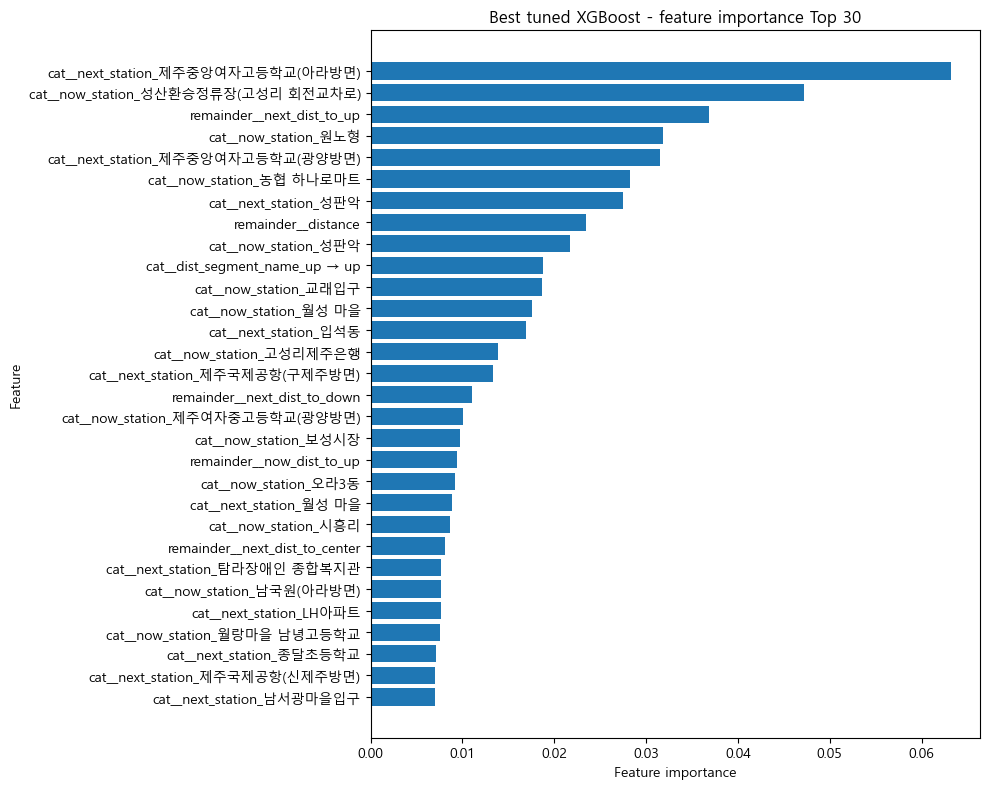

In [48]:
# 상위 30개 feature 를 수평 막대그래프로 그립니다.

top_n = 30
# 그래프는 아래에서 위로 그려지므로, 보기 좋게 오름차순으로 정렬합니다.
top_importance_df = feature_importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(10, 8))
plt.barh(top_importance_df["feature"], top_importance_df["importance"])
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Best tuned XGBoost - feature importance Top 30")
plt.tight_layout()
plt.show()

### 원래 feature 단위로 묶은 특성중요도

위 그래프는 One-Hot Encoding 이후 쪼개진 세부 컬럼 기준이라 해석이 어렵습니다. 그래서 쪼개진 컬럼들을 원래 feature 단위로 다시 묶어 봅니다.

예를 들어 아래 세부 컬럼들의 중요도를 모두 합쳐 `now_station` 하나로 표시합니다.

```
cat__now_station_제주공항
cat__now_station_동문로터리
cat__now_station_시청
        ↓
   now_station
```


In [49]:
def get_original_feature_name(transformed_name, categorical_features, numeric_features):
    """
    OneHotEncoder 이후의 feature 이름을 원래 feature 이름으로 되돌려 보는 함수입니다.

    예:
    - cat__route_nm_201번 -> route_nm
    - cat__now_station_제주공항 -> now_station
    - remainder__distance -> distance

    주의:
    원래 feature 단위 중요도는 교육용 해석을 위한 보조 지표입니다.
    One-Hot feature를 원래 컬럼명 기준으로 묶은 것이므로,
    세부 feature importance와 완전히 같은 관점은 아닙니다.
    """
    # 범주형은 "cat__" 접두어가 붙습니다. 접두어를 떼고, 어느 원래 컬럼에서 나왔는지 찾습니다.
    if transformed_name.startswith("cat__"):
        name = transformed_name.replace("cat__", "", 1)
        for col in categorical_features:
            if name == col or name.startswith(col + "_"):
                return col
        return name

    # 숫자형(passthrough)은 "remainder__" 접두어가 붙습니다.
    if transformed_name.startswith("remainder__"):
        return transformed_name.replace("remainder__", "", 1)

    return transformed_name

In [50]:
# 각 세부 feature 가 어느 원래 feature 에서 나왔는지 표시한 뒤, 원래 feature 단위로 중요도를 합칩니다.
# (범주형 목록은 selected_categorical_features, 숫자형 목록은 selected_numeric_features 를 사용합니다.)
if len(transformed_feature_names) == len(best_xgb_model.feature_importances_):
    feature_importance_df["original_feature"] = feature_importance_df["feature"].apply(
        lambda x: get_original_feature_name(
            x,
            selected_categorical_features,
            selected_numeric_features,
        )
    )

    grouped_importance_df = (
        feature_importance_df
        .groupby("original_feature", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    display(grouped_importance_df)

,original_feature,importance
0,now_station,0.463984
1,next_station,0.402405
2,next_dist_to_up,0.036898
3,distance,0.023465
4,dist_segment_name,0.021581
5,next_dist_to_down,0.011034
6,now_dist_to_up,0.009397
7,next_dist_to_center,0.008103
8,next_dist_to_right,0.006883
9,now_dist_to_down,0.005107


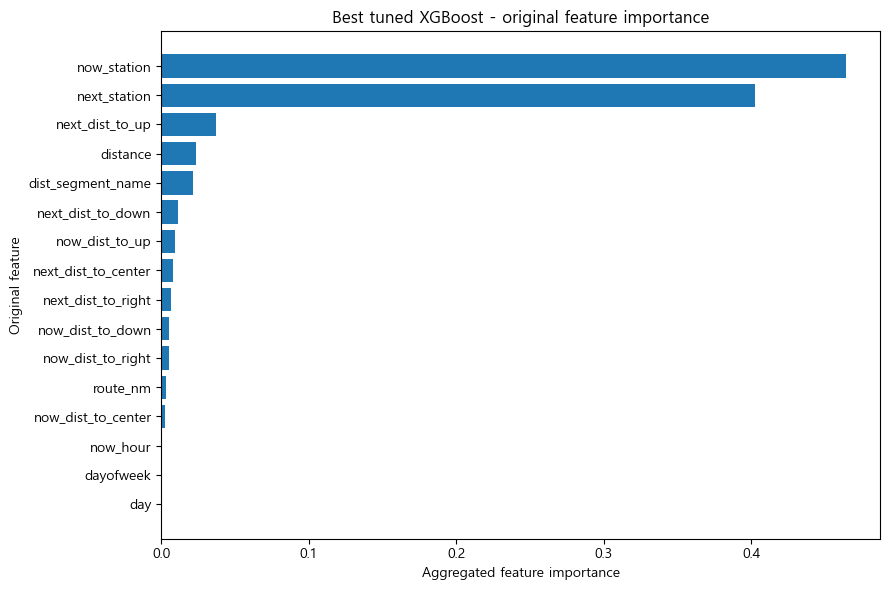

In [51]:
# 원래 feature 단위 중요도를 수평 막대그래프로 그립니다.
if len(transformed_feature_names) == len(best_xgb_model.feature_importances_):
    plot_grouped_df = grouped_importance_df.sort_values("importance")

    plt.figure(figsize=(9, 6))
    plt.barh(plot_grouped_df["original_feature"], plot_grouped_df["importance"])
    plt.xlabel("Aggregated feature importance")
    plt.ylabel("Original feature")
    plt.title("Best tuned XGBoost - original feature importance")
    plt.tight_layout()
    plt.show()

## 16. dtreeviz를 활용한 트리 구조 시각화

XGBoost는 하나의 큰 트리가 아니라 여러 개의 작은 트리를 순서대로 쌓는 앙상블 모델입니다. 따라서 dtreeviz로 보는 `tree_index=0`은 전체 모델이 아니라 **첫 번째 boosting tree 하나**입니다. 이 점을 반드시 기억해야 합니다.

- dtreeviz는 전체 XGBoost 모델을 완전히 설명하지 않습니다. 전체 모델 해석은 특성중요도, 오차 분석, 성능 비교와 함께 종합적으로 봐야 합니다.
- Graphviz 설치, 한글 폰트, SVG/PDF 변환 문제에 주의해야 합니다.


In [52]:
# Graphviz가 Windows 폰트 폴더를 볼 수 있도록 보조 설정
os.environ["GDFONTPATH"] = r"C:\Windows\Fonts"

output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

tree_index = 0

dtreeviz_svg_path = os.path.join(
    output_dir,
    f"xgboost_dtreeviz_tree_{tree_index}.svg"
)

dtreeviz_svg_path

'outputs\\xgboost_dtreeviz_tree_0.svg'

In [53]:
# ----------------------------------------------------------
# 1. 전처리 후 feature 이름 가져오기
# ----------------------------------------------------------
transformed_feature_names = list(best_preprocessor.get_feature_names_out())

transformed_feature_names

['cat__route_nm_201-11',
 'cat__route_nm_201-12',
 'cat__route_nm_201-13',
 'cat__route_nm_201-14',
 'cat__route_nm_201-15',
 'cat__route_nm_201-16',
 'cat__route_nm_201-17',
 'cat__route_nm_201-18',
 'cat__route_nm_201-21',
 'cat__route_nm_201-22',
 'cat__route_nm_201-24',
 'cat__route_nm_201-26',
 'cat__route_nm_201-27',
 'cat__route_nm_281-1',
 'cat__route_nm_281-2',
 'cat__route_nm_360-1',
 'cat__route_nm_360-12',
 'cat__route_nm_360-2',
 'cat__route_nm_360-7',
 'cat__route_nm_365-21',
 'cat__route_nm_365-22',
 'cat__now_station_911의원',
 'cat__now_station_LH아파트',
 'cat__now_station_가마초등학교',
 'cat__now_station_가흥동',
 'cat__now_station_거로 입구',
 'cat__now_station_견월교',
 'cat__now_station_계룡동',
 'cat__now_station_고도농원',
 'cat__now_station_고래왓',
 'cat__now_station_고망난돌입구',
 'cat__now_station_고산동산(광양방면)',
 'cat__now_station_고산동산(아라방면)',
 'cat__now_station_고성리 구 성산농협',
 'cat__now_station_고성리 성산농협',
 'cat__now_station_고성리제주은행',
 'cat__now_station_고성오일시장',
 'cat__now_station_고으니모르 국립제주박물관',

In [54]:
# ----------------------------------------------------------
# 2. dtreeviz에 표시할 짧은 feature 이름 만들기
# ----------------------------------------------------------
short_feature_names = []

for name in transformed_feature_names:
    short_name = (
        name
        .replace("cat__route_nm_", "route_")
        .replace("cat__now_station_", "now_")
        .replace("cat__next_station_", "next_")
        .replace("cat__dist_segment_name_", "segment_")
        .replace("remainder__", "")
    )
    short_feature_names.append(short_name)

short_feature_names

['route_201-11',
 'route_201-12',
 'route_201-13',
 'route_201-14',
 'route_201-15',
 'route_201-16',
 'route_201-17',
 'route_201-18',
 'route_201-21',
 'route_201-22',
 'route_201-24',
 'route_201-26',
 'route_201-27',
 'route_281-1',
 'route_281-2',
 'route_360-1',
 'route_360-12',
 'route_360-2',
 'route_360-7',
 'route_365-21',
 'route_365-22',
 'now_911의원',
 'now_LH아파트',
 'now_가마초등학교',
 'now_가흥동',
 'now_거로 입구',
 'now_견월교',
 'now_계룡동',
 'now_고도농원',
 'now_고래왓',
 'now_고망난돌입구',
 'now_고산동산(광양방면)',
 'now_고산동산(아라방면)',
 'now_고성리 구 성산농협',
 'now_고성리 성산농협',
 'now_고성리제주은행',
 'now_고성오일시장',
 'now_고으니모르 국립제주박물관',
 'now_공업단지 입구',
 'now_공천포',
 'now_관덕정',
 'now_광대왓',
 'now_광양',
 'now_광양사거리',
 'now_광지동',
 'now_광치기해변',
 'now_교래입구',
 'now_구 터미널',
 'now_구좌보건지소',
 'now_구좌중앙초등학교',
 'now_국립제주박물관',
 'now_그린카센터',
 'now_금붕사',
 'now_금산목',
 'now_김녕리',
 'now_김녕해수욕장',
 'now_김녕환승정류장(김녕초등학교)',
 'now_꽃동산',
 'now_난산입구',
 'now_난산입구(성산기상대)',
 'now_남국사',
 'now_남국원(광양방면)',
 'now_남국원(아라방면)',
 'now_남녕고등학교',
 'now_남서광마을',

In [55]:
# ----------------------------------------------------------
# 3. dtreeviz용 학습 데이터 생성
# ----------------------------------------------------------
# 전체 X_train을 전처리합니다.
# OneHotEncoder 결과가 sparse matrix일 수 있으므로,
# XGBoost 학습용으로 DataFrame을 만들기 위해 dense로 변환합니다.
#

X_train_transformed = best_preprocessor.transform(X_train)

X_train_transformed = X_train_transformed.toarray()

X_train_viz_df = pd.DataFrame(
    X_train_transformed,
    columns=short_feature_names,
    index=X_train.index,
)

print("dtreeviz용 학습 데이터 shape:", X_train_viz_df.shape)

dtreeviz용 학습 데이터 shape: (166684, 743)


In [56]:
# ----------------------------------------------------------
# 4. 기존 최적 XGBoost 파라미터 가져오기
# ----------------------------------------------------------
best_xgb_params = best_xgb_model.get_params()

viz_xgb_model = XGBRegressor(**best_xgb_params)

In [57]:
# ----------------------------------------------------------
# 5. feature명이 있는 DataFrame으로 시각화 전용 모델 학습
# ----------------------------------------------------------
viz_xgb_model.fit(
    X_train_viz_df,
    y_train
)

print("dtreeviz용 XGBoost 모델 학습 완료")
print("booster feature_names 예시:")
print(viz_xgb_model.get_booster().feature_names[:20])

dtreeviz용 XGBoost 모델 학습 완료
booster feature_names 예시:
['route_201-11', 'route_201-12', 'route_201-13', 'route_201-14', 'route_201-15', 'route_201-16', 'route_201-17', 'route_201-18', 'route_201-21', 'route_201-22', 'route_201-24', 'route_201-26', 'route_201-27', 'route_281-1', 'route_281-2', 'route_360-1', 'route_360-12', 'route_360-2', 'route_360-7', 'route_365-21']


In [58]:
# ----------------------------------------------------------
# 6. dtreeviz용 샘플 데이터 준비
# ----------------------------------------------------------
sample_size = min( 1000, len(X_train_viz_df))

X_train_viz_sample = X_train_viz_df.sample(
    n=sample_size,
    random_state=42,
)

y_train_viz_sample = y_train.loc[X_train_viz_sample.index]

print("dtreeviz 시각화용 샘플 수:", len(X_train_viz_sample))

dtreeviz 시각화용 샘플 수: 1000


In [59]:
from dtreeviz import model as dtreeviz_model

# ----------------------------------------------------------
# 7. dtreeviz 생성
# ----------------------------------------------------------
viz = dtreeviz_model(
    viz_xgb_model,
    X_train_viz_sample,
    y_train_viz_sample,
    feature_names=list(X_train_viz_sample.columns),
    target_name=target_col,
    tree_index=tree_index,
)

In [60]:
# ----------------------------------------------------------
# 8. SVG 저장
# ----------------------------------------------------------
# 현재 dtreeviz 버전에서는 viz.view().save() 방식이 필요합니다.
viz_render = viz.view()
viz_render.save(dtreeviz_svg_path)

print("dtreeviz SVG 저장 완료:")
print(os.path.abspath(dtreeviz_svg_path))

dtreeviz SVG 저장 완료:
c:\ai_project01\머신러닝\1_10~11 정보활용 버스시간 예측 및 파라메터 튜닝 모델 시각화\outputs\xgboost_dtreeviz_tree_0.svg


In [61]:
# ----------------------------------------------------------
# 9. SVG 내부에 한글 폰트 스타일 삽입
# ----------------------------------------------------------
svg_file = Path(dtreeviz_svg_path)
svg_text = svg_file.read_text(encoding="utf-8")

korean_font_style = """
<style>
text {
font-family: "Malgun Gothic", "맑은 고딕", "Noto Sans CJK KR", sans-serif !important;
}
</style>
"""

# <svg ...> 태그 바로 뒤에 style 삽입
insert_pos = svg_text.find(">") + 1
svg_text = svg_text[:insert_pos] + korean_font_style + svg_text[insert_pos:]

svg_file.write_text(svg_text, encoding="utf-8")

print("SVG 파일에 한글 폰트 스타일을 추가했습니다.")

SVG 파일에 한글 폰트 스타일을 추가했습니다.


> 생성된 `outputs/xgboost_dtreeviz_tree_0.svg` 파일을 열어보면 XGBoost의 첫 번째 boosting tree가 어떤 조건으로 데이터를 나누는지(예: `distance`, `next_dist_to_up`, `now_dist_to_up` 등의 분기 조건) 시각적으로 확인할 수 있습니다.


## 17. 모델 저장 — 예측 서비스 배포 준비

feature 선정과 하이퍼파라미터 튜닝을 완료했습니다. 최종 확정된 모델을 저장하여 이후 예측에 사용합니다.


In [62]:
import joblib

# 최종 모델(Pipeline 전체) 저장
joblib.dump(best_model, "jeju_bus_xgb_final.pkl")

# 저장된 모델 불러오기 및 예측
loaded_model = joblib.load("jeju_bus_xgb_final.pkl")
# X_new 자리에는 새로 예측하고 싶은 데이터(selected_features 컬럼을 갖춘 DataFrame)를 넣습니다.
# y_pred = loaded_model.predict(X_new)

## 마무리 — 이 실습에서 배운 것

1. **문제 정의**: `next_arrive_time` 예측 = 회귀 문제. target과 feature를 명확히 구분합니다.
2. **데이터 준비**: 날짜·시간·위치 feature 생성, 상위 1% 이상치 제거, train/test split.
3. **전처리 Pipeline**: `ColumnTransformer` + `OneHotEncoder` + XGBoost를 하나의 흐름으로 묶습니다.
4. **기준 모델 학습**: `selected_base_xgb` MAE 22.0203초. 모든 튜닝 모델의 비교 기준선입니다.
5. **수동 + 자동 튜닝**: `deep_xgb`, `regularized_xgb` 등 수동 실험과 `RandomizedSearchCV` 자동 튜닝(`best_tuned_xgb`)을 비교합니다. 자동 튜닝이 항상 최고는 아닙니다.
6. **결과 해석**: feature importance, 오차 분석, 개별 예측 비교로 모델을 입체적으로 이해합니다.
7. **모델 시각화**: `dtreeviz`로 첫 번째 boosting tree의 분기 구조를 시각적으로 확인합니다 (전체 모델의 설명은 아님에 유의).
8. **모델 저장**: `joblib`으로 Pipeline 전체를 저장하고, 새로운 데이터에 `predict()`를 적용해 배포를 준비합니다.
